# Copyright (C) 2026 Bruno Proença de Souza
# Licenciado sob GNU AGPL v3 - veja o arquivo LICENSE

# K-Means como Aprendizado de Máquina — Avaliação vs. Classes Pré-Definidas

**Objetivo:** Usar exclusivamente as features `*dec*` (variáveis climáticas decendiais) para o K-Means,  
comparar os clusters gerados com as 4 classes pré-definidas por rendimento médio e calcular métricas completas.

**Métricas:** Acurácia · Matriz de Confusão · Recall · Precisão · Especificidade · F1-Score · AUC-ROC

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from __future__ import annotations
import warnings, unicodedata
from pathlib import Path
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.dpi'         : 130,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'font.size'          : 10,
    'axes.titlesize'     : 11,
    'axes.labelsize'     : 10,
})

# ── Config ────────────────────────────────────────────────────────────────────
PARQUET_PATH  = Path(r'C:\Users\bruno\Desktop\Pipeline_TCC\data\processed\dataset_final.parquet')
K             = 4
TARGET_COL    = 'Rendimento médio da produção (Quilogramas por Hectare)'

# Paleta — Classe 1 (pior) → Classe 4 (melhor)
CLASS_LABELS  = ['Classe 1\nBaixo', 'Classe 2\nMédio-Baixo',
                 'Classe 3\nMédio-Alto', 'Classe 4\nAlto']
PALETTE       = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
CMAP_DISC     = ListedColormap(PALETTE)

In [2]:
# ── Utilitário ────────────────────────────────────────────────────────────────
def find_col(df: pd.DataFrame, name: str) -> str:
    """Busca coluna por nome exato ou aproximado (case/acento-insensitive)."""
    def norm(s): 
        return unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode().lower()
    target = norm(name)
    for col in df.columns:
        if norm(col) == target:
            return col
    for col in df.columns:
        if target in norm(col):
            return col
    raise KeyError(f'Coluna não encontrada: {name}')


def best_label_alignment(y_true: np.ndarray, y_pred: np.ndarray, n: int) -> np.ndarray:
    """
    Encontra o melhor mapeamento entre rótulos do K-Means e das classes pré-definidas
    usando o algoritmo húngaro (maximiza sobreposição na diagonal da matriz de confusão).
    Retorna y_pred remapeado.
    """
    cm   = confusion_matrix(y_true, y_pred, labels=list(range(n)))
    row, col = linear_sum_assignment(-cm)          # maximizar = minimizar negativo
    mapping  = {c: r for r, c in zip(row, col)}
    return np.array([mapping[v] for v in y_pred])

## 1 — Leitura e seleção de features

In [3]:
df = pd.read_parquet(PARQUET_PATH)

# Features: APENAS colunas com 'dec' no nome
# (latitude e longitude são EXCLUÍDAS automaticamente desta seleção)
feat_cols = [c for c in df.columns if 'dec' in c.lower()]

# Confirmar que coordenadas não estão nas features
coord_in_features = [c for c in feat_cols if 'lat' in c.lower() or 'lon' in c.lower()]
if coord_in_features:
    feat_cols = [c for c in feat_cols if c not in coord_in_features]
    print(f'⚠ Removidas colunas de coordenadas de features: {coord_in_features}')

# Target
target_col = find_col(df, TARGET_COL)

print(f'Total de colunas na base  : {df.shape[1]}')
print(f'Features dec selecionadas : {len(feat_cols)}')
print(f'Coluna target             : {target_col}')
print(f'Registros (linhas)        : {len(df):,}')

Total de colunas na base  : 8223
Features dec selecionadas : 8208
Coluna target             : Rendimento médio da produção (Quilogramas por Hectare)
Registros (linhas)        : 2,793


## 2 — Construção do dataset de trabalho

In [4]:
# Trabalhar ao nível de município (média histórica) — mesmo critério do mapa IDW
# Identificadores mínimos para agregar
cod_col = find_col(df, 'cod_ibge')

agg = {c: 'mean' for c in feat_cols}
agg[target_col] = 'mean'

# Preservar coordenadas (latitude, longitude) para interpolação IDW posterior
for coord in ['latitude', 'longitude']:
    if coord in df.columns:
        agg[coord] = 'first'  # mesmo município tem mesma coordenada

mun = df.groupby(cod_col).agg(agg).reset_index()

# Remover municípios com cobertura < 70% nas features dec
cover = mun[feat_cols].notna().mean(axis=1)
mun   = mun[cover >= 0.70].copy()

# Preencher NaN restantes com a mediana
X_raw = mun[feat_cols].copy()
X_raw = X_raw.fillna(X_raw.median())
y_rend = mun[target_col].values

print(f'Municípios no dataset final: {len(mun)}')
print(f'Shape da matriz de features: {X_raw.shape}')

Municípios no dataset final: 399
Shape da matriz de features: (399, 8208)


## 3 — Classes pré-definidas (ground truth por quartis do rendimento)

In [5]:
# Quartis do rendimento → 4 classes ordenadas (0=pior .. 3=melhor)
mun['y_true'] = pd.qcut(
    mun[target_col],
    q=4,
    labels=[0, 1, 2, 3],
).astype(int)

y_true = mun['y_true'].values

dist = pd.Series(y_true).value_counts().sort_index()
print('Distribuição das classes pré-definidas (quartis):')
for i, label in enumerate(CLASS_LABELS):
    lbl_clean = label.replace('\n', ' ')
    print(f'  {lbl_clean}: {dist[i]} municípios '
          f'({dist[i]/len(y_true)*100:.1f}%)')

Distribuição das classes pré-definidas (quartis):
  Classe 1 Baixo: 100 municípios (25.1%)
  Classe 2 Médio-Baixo: 100 municípios (25.1%)
  Classe 3 Médio-Alto: 99 municípios (24.8%)
  Classe 4 Alto: 100 municípios (25.1%)


## 4 — K-Means sobre features dec (com PCA)

In [6]:
# Padronização
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

# PCA — componentes que explicam ≥ 85%
pca_probe = PCA(random_state=42).fit(X_sc)
cum_var   = np.cumsum(pca_probe.explained_variance_ratio_)
n_comp    = max(int(np.searchsorted(cum_var, 0.85)) + 1, 5)

pca   = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_sc)

print(f'PCA: {n_comp} componentes → {cum_var[n_comp-1]*100:.1f}% variância')

# K-Means
km = KMeans(n_clusters=K, random_state=42, n_init=20, max_iter=500)
raw_clusters = km.fit_predict(X_pca)

# Alinhamento ótimo de rótulos via algoritmo húngaro
y_pred_aligned = best_label_alignment(y_true, raw_clusters, K)
mun['y_pred']  = y_pred_aligned

print(f'K-Means concluído — {K} clusters')
print('Distribuição dos clusters (após alinhamento):')
for i, label in enumerate(CLASS_LABELS):
    n = (y_pred_aligned == i).sum()
    print(f'  {label.replace(chr(10)," ")}: {n} municípios ({n/len(y_pred_aligned)*100:.1f}%)')

PCA: 5 componentes → 85.1% variância
K-Means concluído — 4 clusters
Distribuição dos clusters (após alinhamento):
  Classe 1 Baixo: 85 municípios (21.3%)
  Classe 2 Médio-Baixo: 138 municípios (34.6%)
  Classe 3 Médio-Alto: 99 municípios (24.8%)
  Classe 4 Alto: 77 municípios (19.3%)


## 5 — Métricas globais

In [7]:
# ── Acurácia ──────────────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred_aligned)

# ── Precisão, Recall, F1 (macro e por classe) ────────────────────────────────
prec_macro  = precision_score(y_true, y_pred_aligned, average='macro',  zero_division=0)
rec_macro   = recall_score   (y_true, y_pred_aligned, average='macro',  zero_division=0)
f1_macro    = f1_score       (y_true, y_pred_aligned, average='macro',  zero_division=0)

prec_w = precision_score(y_true, y_pred_aligned, average='weighted', zero_division=0)
rec_w  = recall_score   (y_true, y_pred_aligned, average='weighted', zero_division=0)
f1_w   = f1_score       (y_true, y_pred_aligned, average='weighted', zero_division=0)

# ── Especificidade por classe (TN/TN+FP) ─────────────────────────────────────
cm_full  = confusion_matrix(y_true, y_pred_aligned)
spec_per_class = []
for i in range(K):
    TP = cm_full[i, i]
    FN = cm_full[i, :].sum() - TP
    FP = cm_full[:, i].sum() - TP
    TN = cm_full.sum() - TP - FN - FP
    spec_per_class.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
spec_macro = np.mean(spec_per_class)

# ── AUC-ROC (OvR multiclasse) ────────────────────────────────────────────────
y_true_bin  = label_binarize(y_true,        classes=[0,1,2,3])
y_pred_bin  = label_binarize(y_pred_aligned, classes=[0,1,2,3])

# Probabilidades simuladas: distância ao centróide (invertida e normalizada)
# → abordagem válida para K-Means, que não produz probabilidades nativas
dists_to_centers = km.transform(X_pca)          # (N, K) distâncias aos centróides
# Alinhar colunas com o mapeamento de rótulos
mapping_inv = {}   # cluster_raw → y_true_space
for raw_label in range(K):
    aligned_label = y_pred_aligned[raw_clusters == raw_label]
    if len(aligned_label) > 0:
        mapping_inv[raw_label] = int(np.bincount(aligned_label).argmax())

dists_aligned = np.zeros_like(dists_to_centers)
for raw_col, true_col in mapping_inv.items():
    dists_aligned[:, true_col] = dists_to_centers[:, raw_col]

# Converter distância → pseudo-probabilidade (softmax invertido)
inv_dist   = 1.0 / (dists_aligned + 1e-9)
proba_soft = inv_dist / inv_dist.sum(axis=1, keepdims=True)

auc_ovr = roc_auc_score(y_true_bin, proba_soft, multi_class='ovr', average='macro')
auc_per_class = [
    roc_auc_score(y_true_bin[:, i], proba_soft[:, i])
    for i in range(K)
]

# ── Relatório compacto ────────────────────────────────────────────────────────
print('=' * 58)
print(f'  MÉTRICAS GLOBAIS — K-Means (K={K}) vs. Classes Pré-Definidas')
print('=' * 58)
print(f'  Acurácia                  : {acc*100:.2f}%')
print(f'  Precisão  (macro)         : {prec_macro*100:.2f}%')
print(f'  Recall    (macro)         : {rec_macro*100:.2f}%')
print(f'  F1-Score  (macro)         : {f1_macro*100:.2f}%')
print(f'  Especificidade (macro)    : {spec_macro*100:.2f}%')
print(f'  AUC-ROC   (OvR, macro)   : {auc_ovr:.4f}')
print('─' * 58)
print(f'  Precisão  (weighted)      : {prec_w*100:.2f}%')
print(f'  Recall    (weighted)      : {rec_w*100:.2f}%')
print(f'  F1-Score  (weighted)      : {f1_w*100:.2f}%')
print('=' * 58)

  MÉTRICAS GLOBAIS — K-Means (K=4) vs. Classes Pré-Definidas
  Acurácia                  : 49.37%
  Precisão  (macro)         : 50.29%
  Recall    (macro)         : 49.38%
  F1-Score  (macro)         : 49.24%
  Especificidade (macro)    : 83.12%
  AUC-ROC   (OvR, macro)   : 0.7488
──────────────────────────────────────────────────────────
  Precisão  (weighted)      : 50.29%
  Recall    (weighted)      : 49.37%
  F1-Score  (weighted)      : 49.23%


## 6 — Métricas por classe

In [8]:
prec_cls  = precision_score(y_true, y_pred_aligned, average=None, zero_division=0)
rec_cls   = recall_score   (y_true, y_pred_aligned, average=None, zero_division=0)
f1_cls    = f1_score       (y_true, y_pred_aligned, average=None, zero_division=0)

metrics_df = pd.DataFrame({
    'Classe'          : [l.replace('\n',' ') for l in CLASS_LABELS],
    'Precisão (%)'    : (prec_cls * 100).round(2),
    'Recall (%)'      : (rec_cls  * 100).round(2),
    'Especific. (%)'  : (np.array(spec_per_class) * 100).round(2),
    'F1-Score (%)'    : (f1_cls   * 100).round(2),
    'AUC-ROC'         : [round(v, 4) for v in auc_per_class],
    'n (ground truth)': [int((y_true == i).sum()) for i in range(K)],
    'n (K-Means)'     : [int((y_pred_aligned == i).sum()) for i in range(K)],
})

print(metrics_df.to_string(index=False))

              Classe  Precisão (%)  Recall (%)  Especific. (%)  F1-Score (%)  AUC-ROC  n (ground truth)  n (K-Means)
      Classe 1 Baixo         52.94       45.00           86.62         48.65   0.7768               100           85
Classe 2 Médio-Baixo         42.75       59.00           73.58         49.58   0.7396               100          138
 Classe 3 Médio-Alto         53.54       53.54           84.67         53.54   0.7115                99           99
       Classe 4 Alto         51.95       40.00           87.63         45.20   0.7676               100           77


## 7 — Painel de métricas por classe (gráfico)

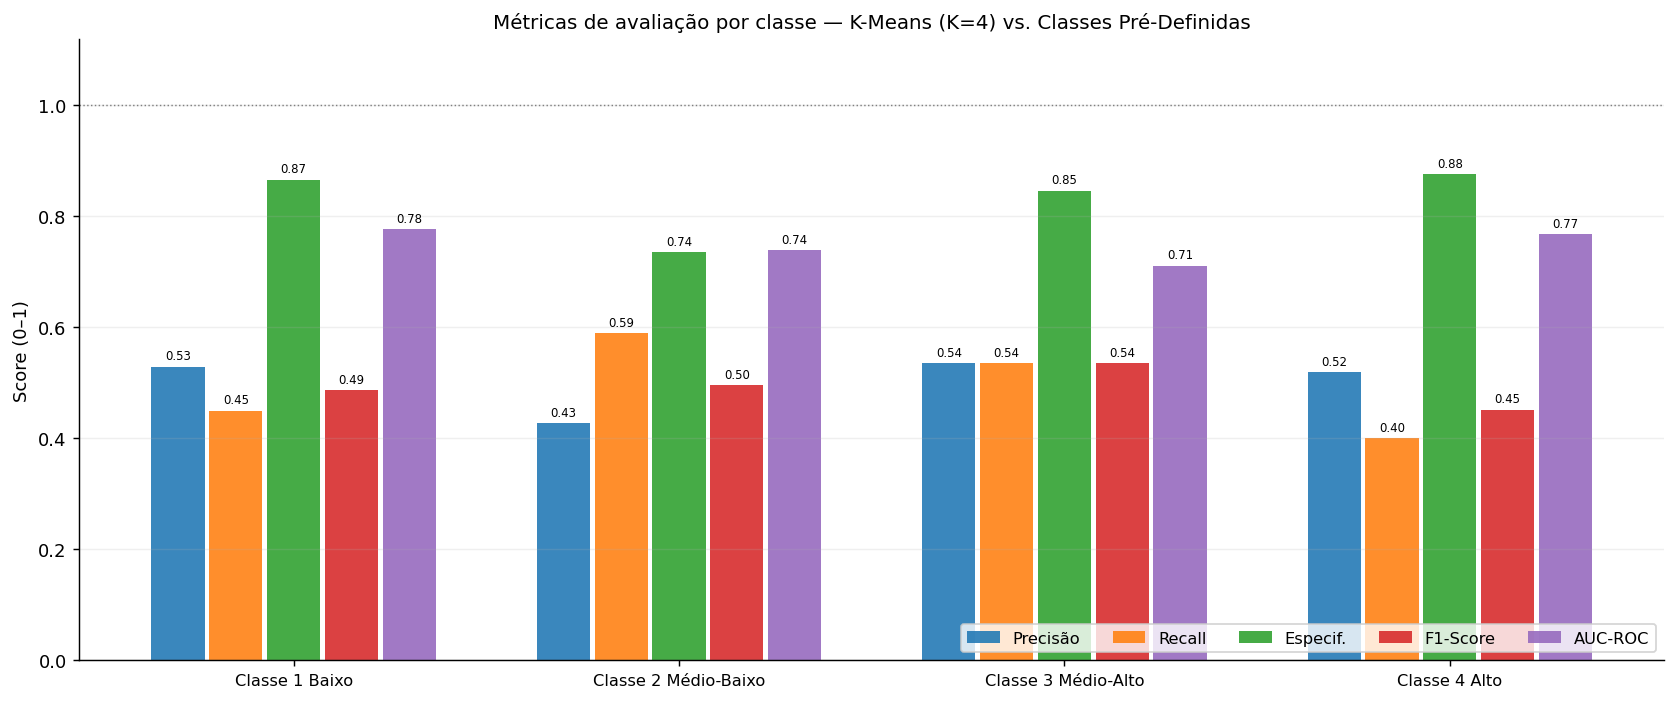

In [9]:
metric_names  = ['Precisão', 'Recall', 'Especif.', 'F1-Score', 'AUC-ROC']
metric_values = [
    prec_cls,
    rec_cls,
    np.array(spec_per_class),
    f1_cls,
    np.array(auc_per_class),
]

x     = np.arange(K)
width = 0.15
offsets = np.linspace(-(len(metric_names)-1)/2, (len(metric_names)-1)/2, len(metric_names)) * width

fig, ax = plt.subplots(figsize=(13, 5.5))
for i, (mname, mvals, offset) in enumerate(zip(metric_names, metric_values, offsets)):
    bars = ax.bar(x + offset, mvals, width=width*0.92,
                   label=mname, alpha=0.88,
                   color=plt.cm.tab10(i))
    for bar, val in zip(bars, mvals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=6.5, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('\n',' ') for l in CLASS_LABELS], fontsize=9)
ax.set_ylabel('Score (0–1)')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.legend(fontsize=9, loc='lower right', ncol=5)
ax.grid(axis='y', alpha=0.2)
ax.set_title('Métricas de avaliação por classe — K-Means (K=4) vs. Classes Pré-Definidas')
plt.tight_layout()
plt.show()

## 8 — Matriz de Confusão

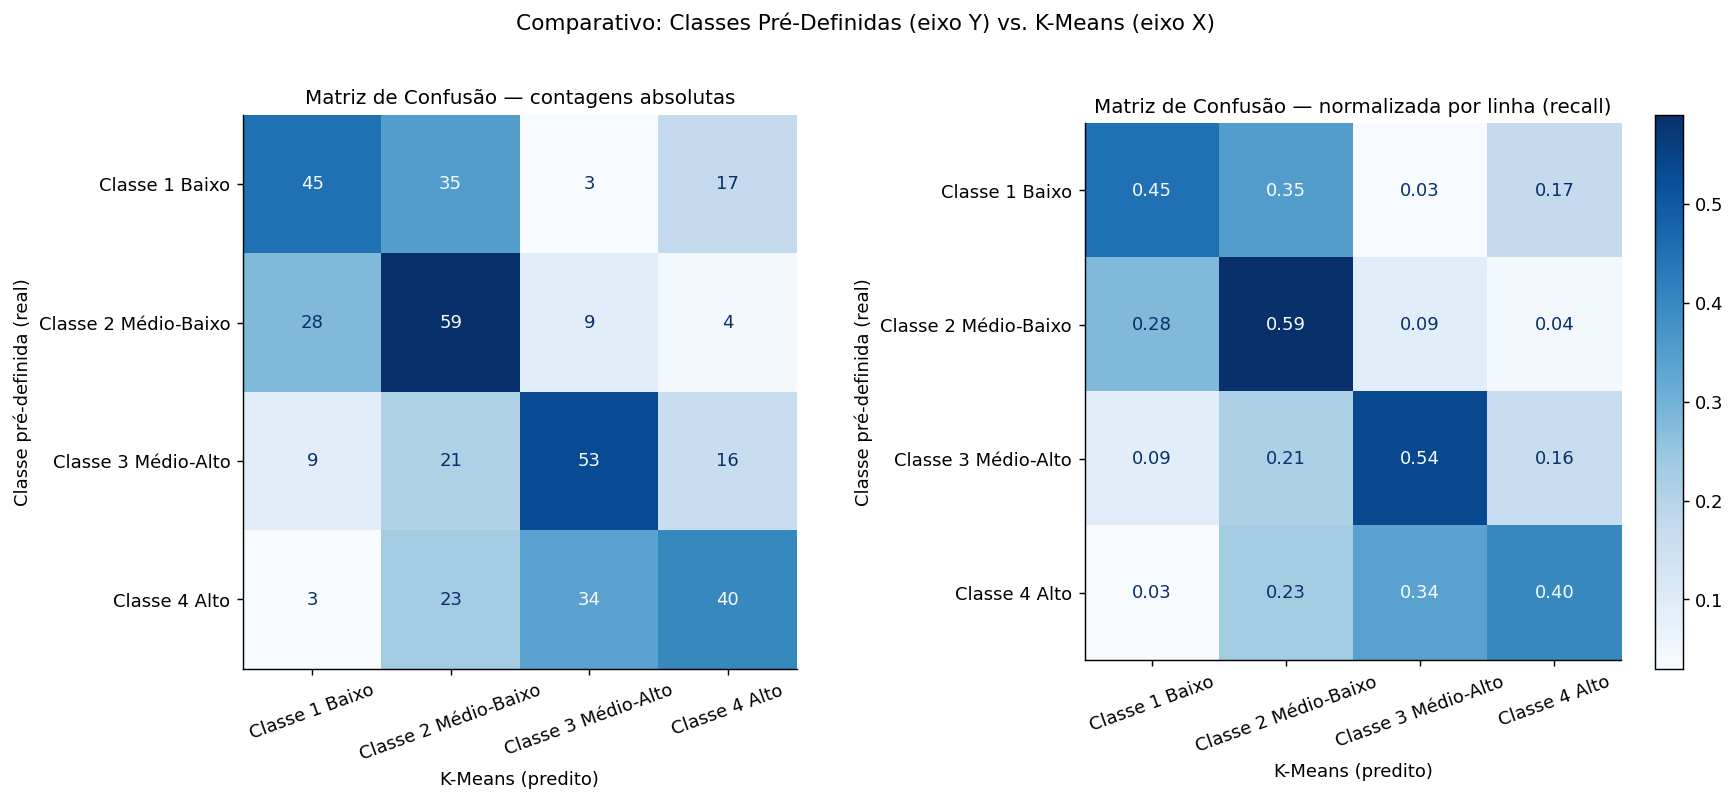

In [10]:
tick_labels = [l.replace('\n',' ') for l in CLASS_LABELS]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Contagens absolutas ───────────────────────────────────────────────────────
ConfusionMatrixDisplay(
    confusion_matrix=cm_full,
    display_labels=tick_labels,
).plot(
    ax=axes[0], cmap='Blues',
    colorbar=False, xticks_rotation=20,
)
axes[0].set_title('Matriz de Confusão — contagens absolutas')
axes[0].set_xlabel('K-Means (predito)')
axes[0].set_ylabel('Classe pré-definida (real)')

# ── Normalizada por linha (recall por célula) ─────────────────────────────────
cm_norm = cm_full.astype(float) / cm_full.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=tick_labels,
).plot(
    ax=axes[1], cmap='Blues',
    colorbar=True, xticks_rotation=20,
    values_format='.2f',
)
axes[1].set_title('Matriz de Confusão — normalizada por linha (recall)')
axes[1].set_xlabel('K-Means (predito)')
axes[1].set_ylabel('Classe pré-definida (real)')

plt.suptitle('Comparativo: Classes Pré-Definidas (eixo Y) vs. K-Means (eixo X)',
              fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9 — Curvas ROC por classe (One-vs-Rest)

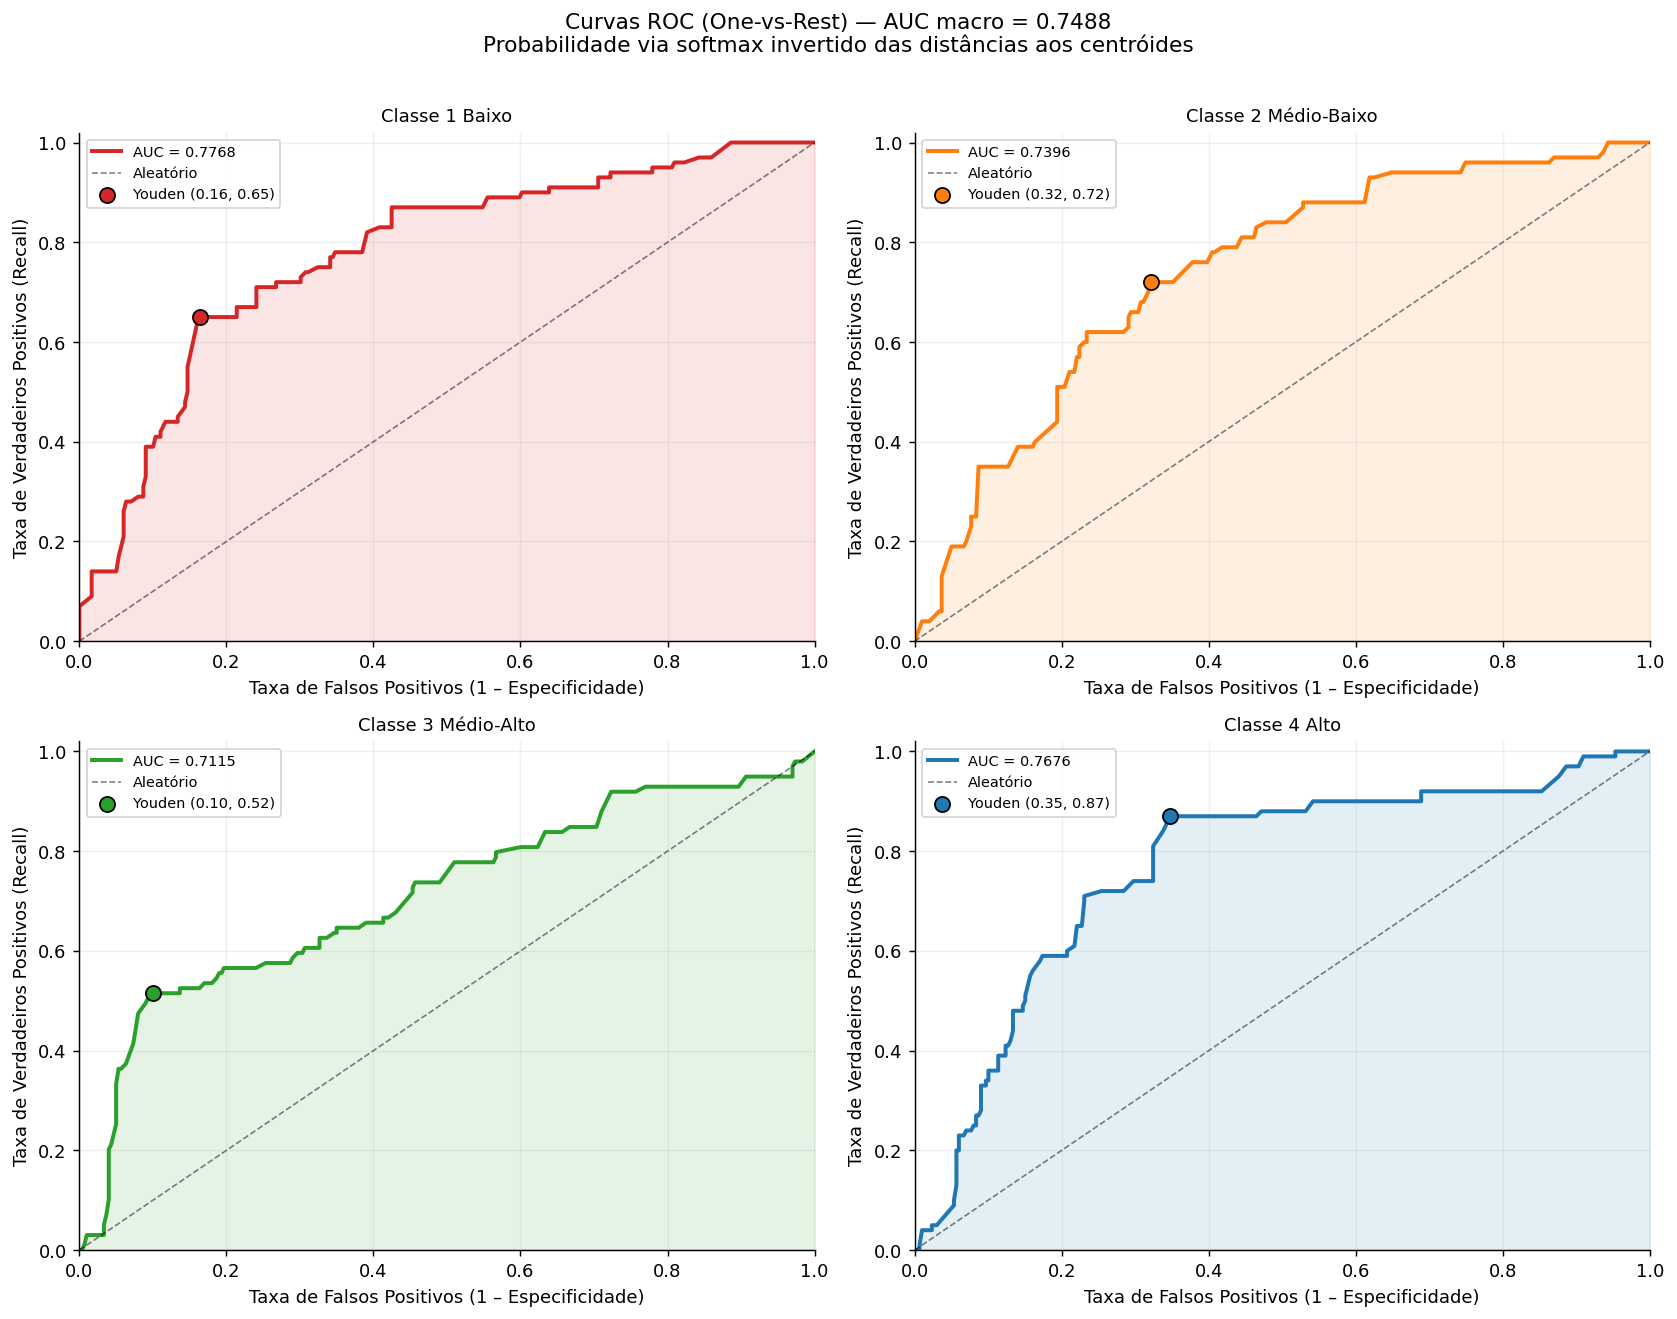

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for i in range(K):
    ax     = axes[i]
    color  = PALETTE[i]
    label  = CLASS_LABELS[i].replace('\n', ' ')

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], proba_soft[:, i])
    auc_i       = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2.2,
             label=f'AUC = {auc_i:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.12, color=color)
    ax.plot([0,1],[0,1], 'k--', lw=0.9, alpha=0.5, label='Aleatório')

    ax.set_title(f'{label}', fontsize=10)
    ax.set_xlabel('Taxa de Falsos Positivos (1 – Especificidade)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

    # Ponto de máxima distância à diagonal (Youden)
    youden_idx = np.argmax(tpr - fpr)
    ax.scatter(fpr[youden_idx], tpr[youden_idx],
                s=70, color=color, edgecolors='black', zorder=5,
                label=f'Youden ({fpr[youden_idx]:.2f}, {tpr[youden_idx]:.2f})')
    ax.legend(fontsize=8)

plt.suptitle(f'Curvas ROC (One-vs-Rest) — AUC macro = {auc_ovr:.4f}\n'
              'Probabilidade via softmax invertido das distâncias aos centróides',
              fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 10 — Comparativo visual: distribuição de rendimento por classe

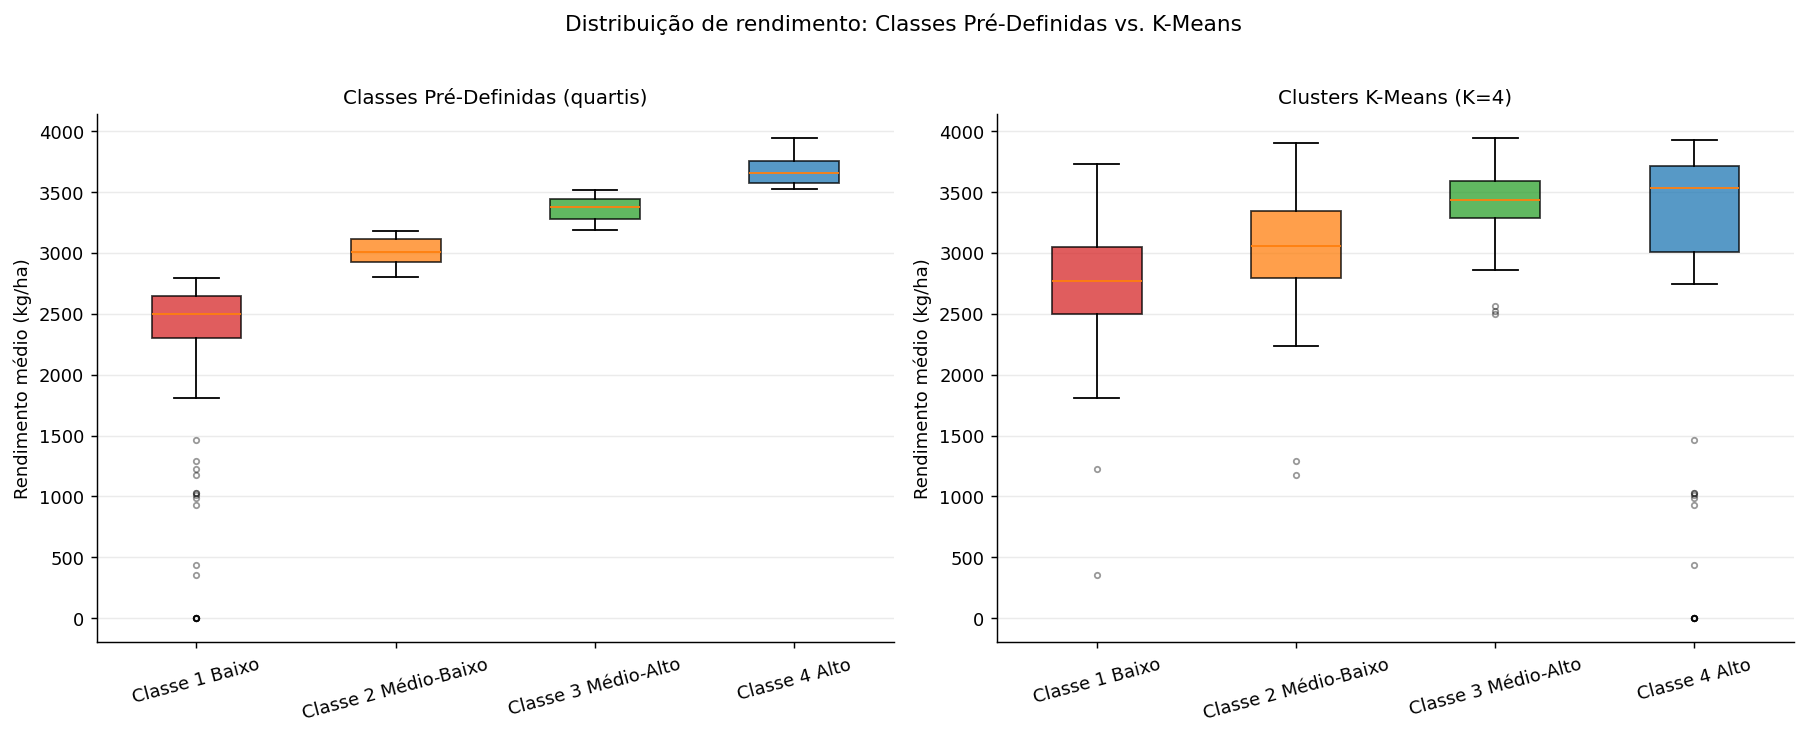

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Boxplot: classes pré-definidas ────────────────────────────────────────────
data_true = [mun.loc[mun['y_true'] == i, target_col].values for i in range(K)]
bp1 = axes[0].boxplot(data_true,
                       tick_labels=[l.replace('\n',' ') for l in CLASS_LABELS],
                       patch_artist=True, showfliers=True,
                       flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp1['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel('Rendimento médio (kg/ha)')
axes[0].set_title('Classes Pré-Definidas (quartis)')
axes[0].tick_params(axis='x', labelrotation=15)
axes[0].grid(axis='y', alpha=0.25)

# ── Boxplot: clusters K-Means ─────────────────────────────────────────────────
data_pred = [mun.loc[mun['y_pred'] == i, target_col].values for i in range(K)]
bp2 = axes[1].boxplot(data_pred,
                       tick_labels=[l.replace('\n',' ') for l in CLASS_LABELS],
                       patch_artist=True, showfliers=True,
                       flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_ylabel('Rendimento médio (kg/ha)')
axes[1].set_title('Clusters K-Means (K=4)')
axes[1].tick_params(axis='x', labelrotation=15)
axes[1].grid(axis='y', alpha=0.25)

plt.suptitle('Distribuição de rendimento: Classes Pré-Definidas vs. K-Means',
              fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 11 — Radar (spider) das métricas por classe

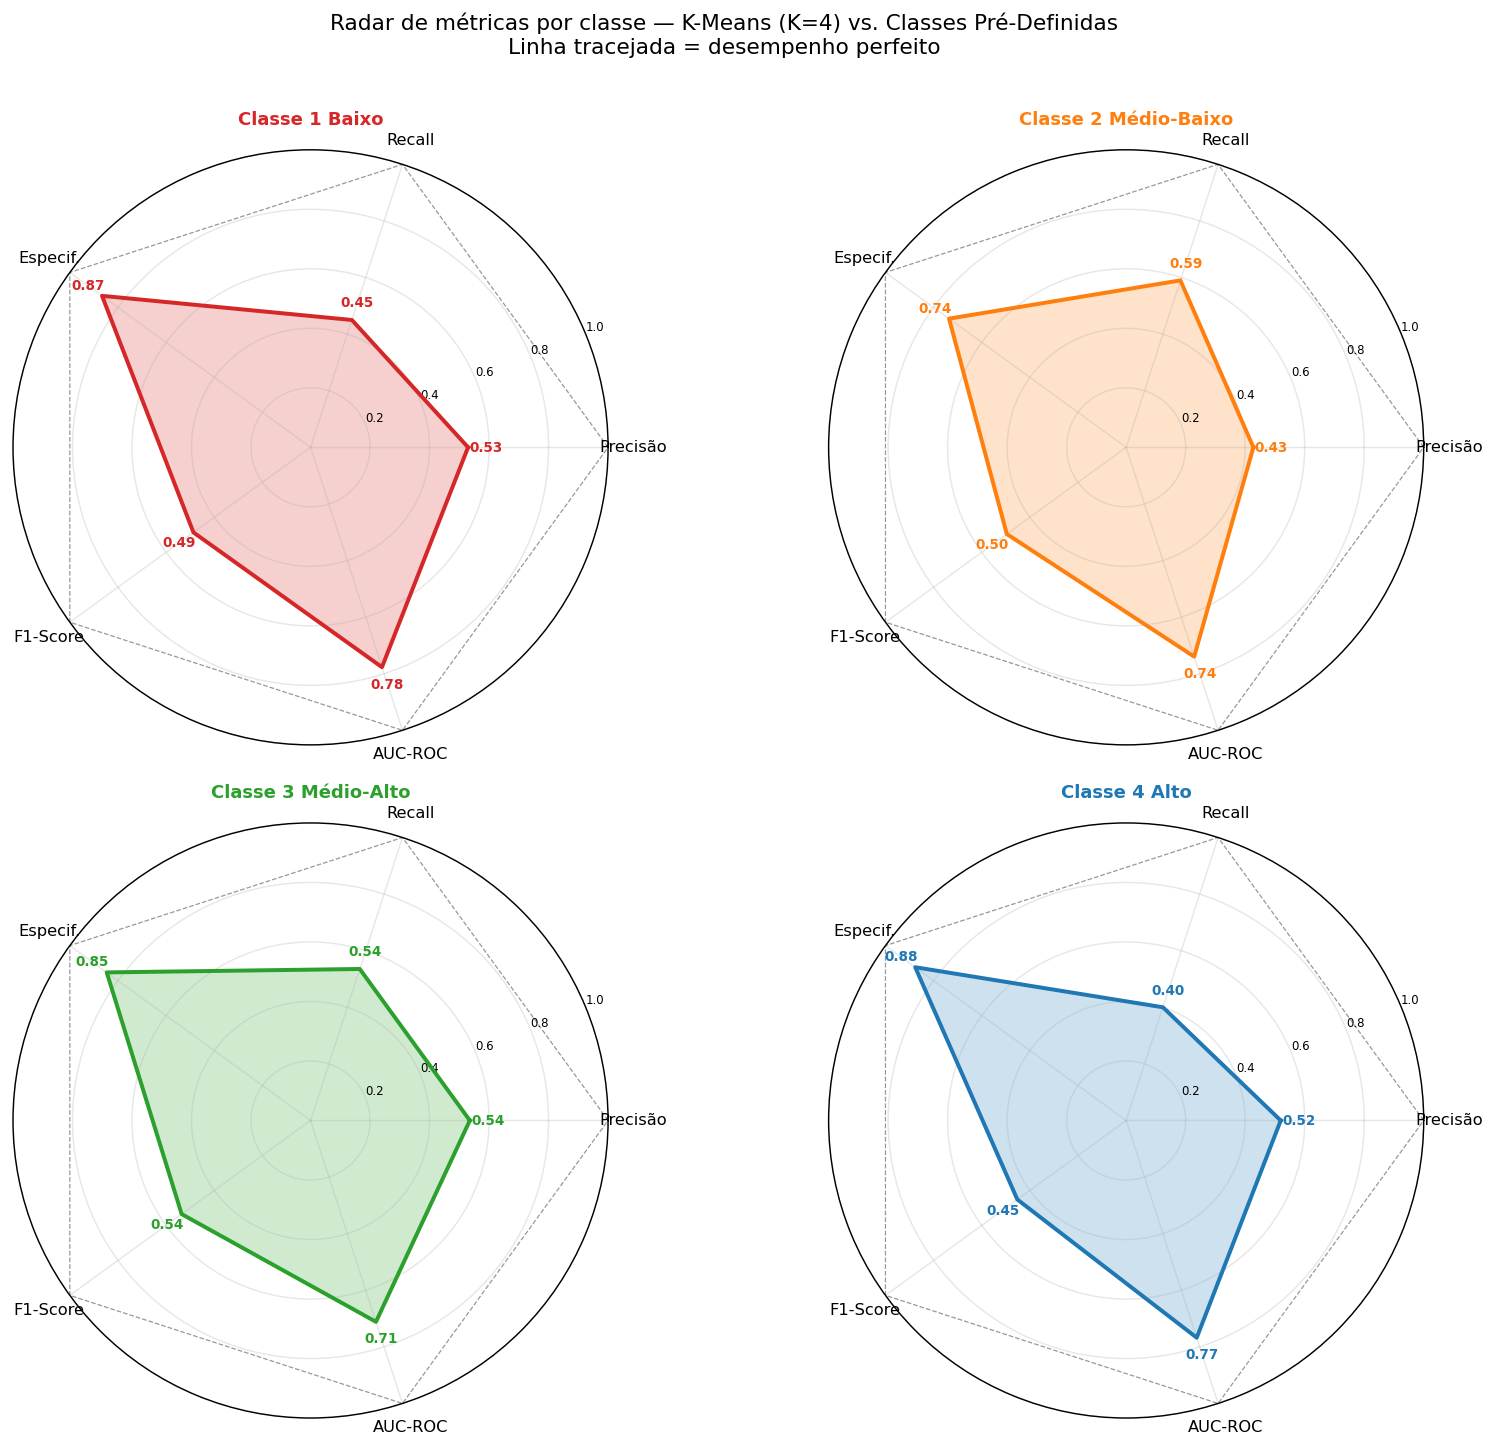

In [13]:
import matplotlib.patches as mpatches

radar_metrics = {
    'Precisão'     : prec_cls,
    'Recall'       : rec_cls,
    'Especif.'     : np.array(spec_per_class),
    'F1-Score'     : f1_cls,
    'AUC-ROC'      : np.array(auc_per_class),
}
rnames = list(radar_metrics.keys())
N_met  = len(rnames)
angles = np.linspace(0, 2 * np.pi, N_met, endpoint=False).tolist()
angles += angles[:1]                          # fechar o polígono

fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                          subplot_kw=dict(polar=True))
axes = axes.ravel()

for i in range(K):
    ax    = axes[i]
    color = PALETTE[i]
    label = CLASS_LABELS[i].replace('\n', ' ')

    values = [radar_metrics[m][i] for m in rnames]
    values += values[:1]

    ax.plot(angles, values, color=color, lw=2.2)
    ax.fill(angles, values, color=color, alpha=0.22)

    # Referência perfeita
    ax.plot(angles, [1]*len(angles), 'k--', lw=0.7, alpha=0.4)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(rnames, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=6.5)
    ax.set_title(label, fontsize=10, pad=14, color=color, fontweight='bold')
    ax.grid(alpha=0.3)

    # Anotar valores nos vértices
    for angle, val, mname in zip(angles[:-1], values[:-1], rnames):
        ax.text(angle, val + 0.06, f'{val:.2f}',
                ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')

plt.suptitle('Radar de métricas por classe — K-Means (K=4) vs. Classes Pré-Definidas\n'
              'Linha tracejada = desempenho perfeito',
              fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 12 — Tabela comparativa final

In [14]:
global_metrics = pd.DataFrame({
    'Métrica': [
        'Acurácia',
        'Precisão macro',
        'Recall macro',
        'Especificidade macro',
        'F1-Score macro',
        'AUC-ROC macro (OvR)',
        '── ponderado ──',
        'Precisão weighted',
        'Recall weighted',
        'F1-Score weighted',
    ],
    'Valor': [
        f'{acc*100:.2f}%',
        f'{prec_macro*100:.2f}%',
        f'{rec_macro*100:.2f}%',
        f'{spec_macro*100:.2f}%',
        f'{f1_macro*100:.2f}%',
        f'{auc_ovr:.4f}',
        '',
        f'{prec_w*100:.2f}%',
        f'{rec_w*100:.2f}%',
        f'{f1_w*100:.2f}%',
    ]
})

print('\n' + '='*42)
print('  RESUMO FINAL DE MÉTRICAS')
print('='*42)
print(global_metrics.to_string(index=False))
print('='*42)
print()
print('─'*60)
print('  MÉTRICAS POR CLASSE')
print('─'*60)
print(metrics_df.to_string(index=False))
print('─'*60)


  RESUMO FINAL DE MÉTRICAS
             Métrica  Valor
            Acurácia 49.37%
      Precisão macro 50.29%
        Recall macro 49.38%
Especificidade macro 83.12%
      F1-Score macro 49.24%
 AUC-ROC macro (OvR) 0.7488
     ── ponderado ──       
   Precisão weighted 50.29%
     Recall weighted 49.37%
   F1-Score weighted 49.23%

────────────────────────────────────────────────────────────
  MÉTRICAS POR CLASSE
────────────────────────────────────────────────────────────
              Classe  Precisão (%)  Recall (%)  Especific. (%)  F1-Score (%)  AUC-ROC  n (ground truth)  n (K-Means)
      Classe 1 Baixo         52.94       45.00           86.62         48.65   0.7768               100           85
Classe 2 Médio-Baixo         42.75       59.00           73.58         49.58   0.7396               100          138
 Classe 3 Médio-Alto         53.54       53.54           84.67         53.54   0.7115                99           99
       Classe 4 Alto         51.95       40.00     

## 13 — Heatmap da tabela de métricas por classe

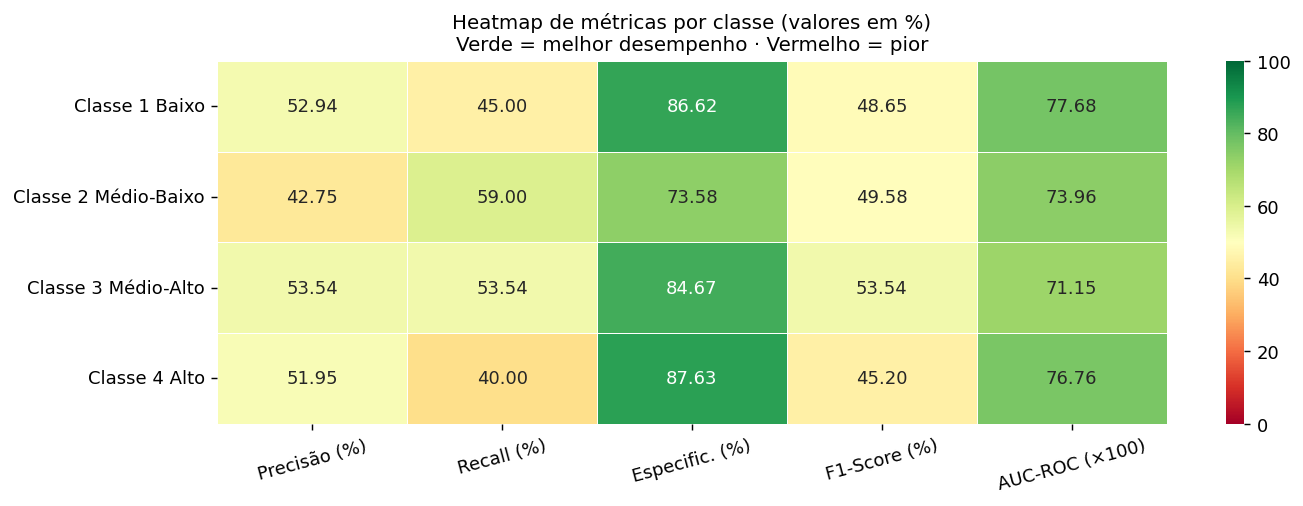

In [15]:
heat_data = metrics_df.set_index('Classe')[[
    'Precisão (%)', 'Recall (%)', 'Especific. (%)', 'F1-Score (%)'
]].copy()

# AUC-ROC em escala 0-100 para ficar comparável
heat_data['AUC-ROC (×100)'] = metrics_df['AUC-ROC'].values * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heat_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'fontsize': 10},
)
ax.set_title('Heatmap de métricas por classe (valores em %)\n'
              'Verde = melhor desempenho · Vermelho = pior',
              fontsize=11)
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
plt.show()

## 14 — Interpolação IDW com limite do Paraná: Classes Pré-Definidas vs. K-Means

Latitude coluna: latitude
Longitude coluna: longitude


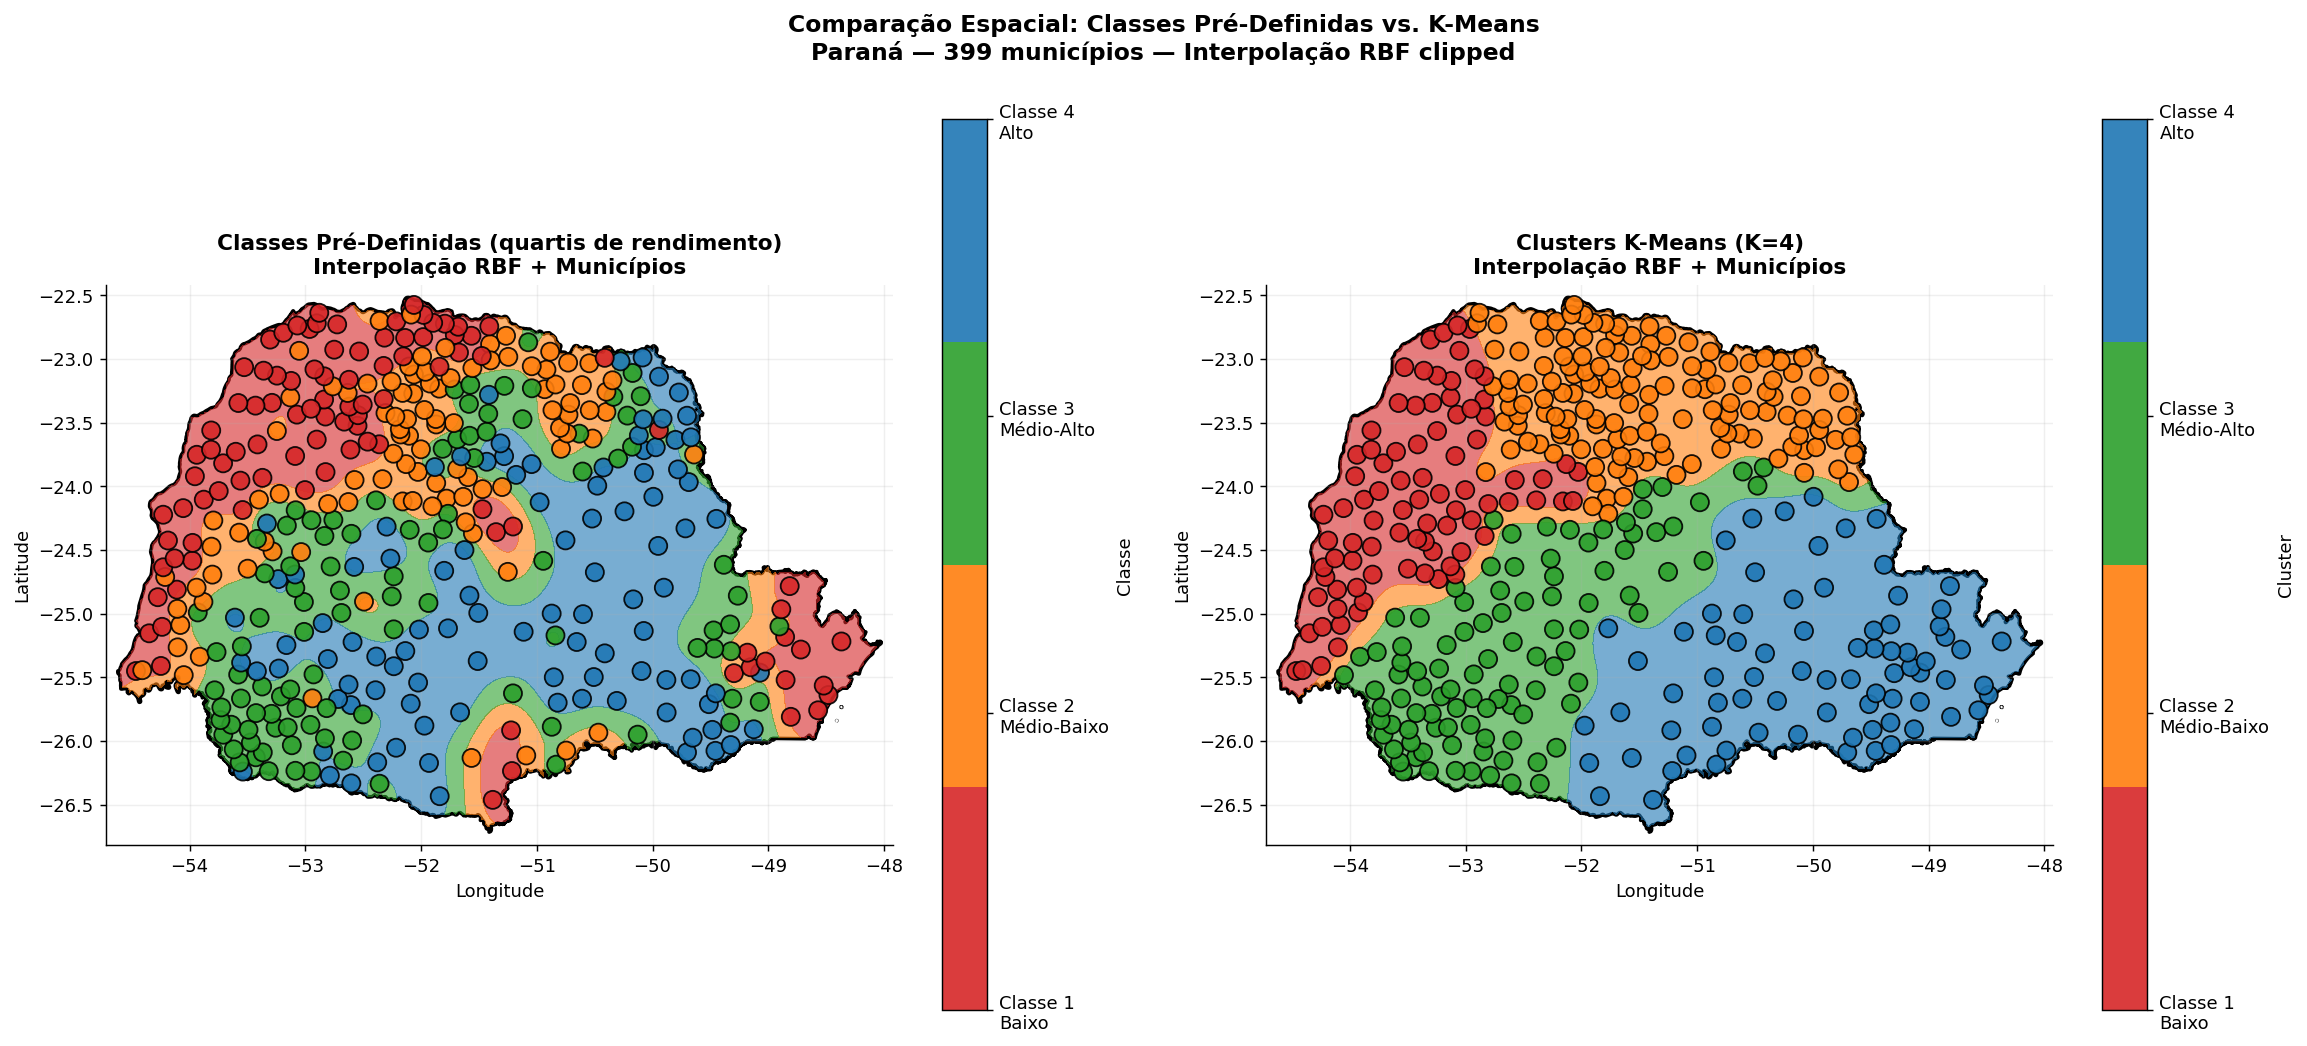

✓ Mapas com interpolação gerados com sucesso!
  • Número de municípios interpolados: 399


In [16]:
try:
    import geobr
    import geopandas as gpd
    from shapely.geometry import Point
    from scipy.interpolate import Rbf
except ImportError:
    print('Instalando dependências: geobr, geopandas, shapely, scipy...')
    import subprocess
    subprocess.check_call(['pip', 'install', '-q', 'geobr', 'geopandas', 'shapely', 'scipy'])
    import geobr
    import geopandas as gpd
    from shapely.geometry import Point
    from scipy.interpolate import Rbf

# ── Obter limite do Paraná via geobr ──────────────────────────────────────────
pr_boundary = geobr.read_state(code_state='PR', year=2020)
pr_bbox = pr_boundary.total_bounds  # (minx, miny, maxx, maxy)

# ── Procurar por colunas de latitude e longitude ────────────────────────────────
lat_col = None
lon_col = None
for col in mun.columns:
    if 'lat' in col.lower():
        lat_col = col
    if 'lon' in col.lower():
        lon_col = col

print(f'Latitude coluna: {lat_col}')
print(f'Longitude coluna: {lon_col}')

if lat_col and lon_col:
    coords_valid = mun[~(mun[[lat_col, lon_col]].isna().any(axis=1))].copy()
    
    if len(coords_valid) > 3:
        # Criar GeoDataFrame e fazer clipping dentro do Paraná
        geometry = [Point(xy) for xy in zip(coords_valid[lon_col], coords_valid[lat_col])]
        gdf = gpd.GeoDataFrame(coords_valid, geometry=geometry, crs='EPSG:4326')
        
        # Clipping: manter só pontos dentro do Paraná
        gdf_clipped = gpd.clip(gdf, pr_boundary)
        
        x_pts = gdf_clipped.geometry.x.values
        y_pts = gdf_clipped.geometry.y.values
        z_true = gdf_clipped['y_true'].values + 1  # Classes 1-4
        z_pred = gdf_clipped['y_pred'].values + 1  # Classes 1-4
        
        # Grid para interpolação dentro do bbox do Paraná
        resolution = 0.02
        x_grid = np.arange(pr_bbox[0], pr_bbox[2], resolution)
        y_grid = np.arange(pr_bbox[1], pr_bbox[3], resolution)
        xx, yy = np.meshgrid(x_grid, y_grid)
        
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        
        # ── Interpolação classes pré-definidas ────────────────────────────────
        rbf_true = Rbf(x_pts, y_pts, z_true, function='multiquadric', smooth=0.1)
        zz_true = rbf_true(xx, yy)
        zz_true = np.clip(zz_true, 1, 4)
        
        # Mascarar pontos fora do Paraná
        from shapely.prepared import prep
        pr_prep = prep(pr_boundary.geometry[0])
        mask = np.array([pr_prep.contains(Point(x, y)) for x, y in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)
        zz_true_masked = np.where(mask, zz_true, np.nan)
        
        ax = axes[0]
        pr_boundary.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
        
        im1 = ax.contourf(xx, yy, zz_true_masked, levels=np.arange(0.5, 5.5, 1), 
                           cmap=CMAP_DISC, alpha=0.6)
        # Scatter dos pontos
        scatter1 = ax.scatter(x_pts, y_pts, c=z_true, cmap=CMAP_DISC, 
                              s=100, edgecolors='black', linewidth=1, 
                              vmin=1, vmax=4, alpha=0.9, zorder=5, marker='o')
        ax.set_title('Classes Pré-Definidas (quartis de rendimento)\nInterpolação RBF + Municípios', 
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        cbar1 = plt.colorbar(scatter1, ax=ax, label='Classe', ticks=[1, 2, 3, 4])
        cbar1.set_ticklabels(CLASS_LABELS)
        ax.grid(alpha=0.2)
        ax.set_xlim(pr_bbox[0] - 0.1, pr_bbox[2] + 0.1)
        ax.set_ylim(pr_bbox[1] - 0.1, pr_bbox[3] + 0.1)
        
        # ── Interpolação clusters K-Means ─────────────────────────────────────
        rbf_pred = Rbf(x_pts, y_pts, z_pred, function='multiquadric', smooth=0.1)
        zz_pred = rbf_pred(xx, yy)
        zz_pred = np.clip(zz_pred, 1, 4)
        
        zz_pred_masked = np.where(mask, zz_pred, np.nan)
        
        ax = axes[1]
        pr_boundary.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
        
        im2 = ax.contourf(xx, yy, zz_pred_masked, levels=np.arange(0.5, 5.5, 1), 
                           cmap=CMAP_DISC, alpha=0.6)
        # Scatter dos pontos
        scatter2 = ax.scatter(x_pts, y_pts, c=z_pred, cmap=CMAP_DISC, 
                              s=100, edgecolors='black', linewidth=1, 
                              vmin=1, vmax=4, alpha=0.9, zorder=5, marker='o')
        ax.set_title('Clusters K-Means (K=4)\nInterpolação RBF + Municípios', 
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        cbar2 = plt.colorbar(scatter2, ax=ax, label='Cluster', ticks=[1, 2, 3, 4])
        cbar2.set_ticklabels(CLASS_LABELS)
        ax.grid(alpha=0.2)
        ax.set_xlim(pr_bbox[0] - 0.1, pr_bbox[2] + 0.1)
        ax.set_ylim(pr_bbox[1] - 0.1, pr_bbox[3] + 0.1)
        
        plt.suptitle(f'Comparação Espacial: Classes Pré-Definidas vs. K-Means\nParaná — {len(gdf_clipped)} municípios — Interpolação RBF clipped',
                     fontsize=13, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
        
        print('✓ Mapas com interpolação gerados com sucesso!')
        print(f'  • Número de municípios interpolados: {len(gdf_clipped)}')
    else:
        print(f'⚠ Insuficientes coordenadas válidas ({len(coords_valid)} < 3)')
else:
    print(f'⚠ Colunas de coordenadas não encontradas.')
    print(f'  Colunas disponíveis em mun: {list(mun.columns[:10])}...')
